In [5]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

wiki = WikipediaQueryRun(
    api_wrapper=WikipediaAPIWrapper()
)

print(wiki.invoke("Artificial Intelligence"))

Page: Artificial intelligence
Summary: Artificial intelligence (AI) is the capability of computational systems to perform tasks typically associated with human intelligence, such as learning, reasoning, problem-solving, perception, and decision-making. It is a field of research in engineering, mathematics and computer science that develops and studies methods and software that enable machines to perceive their environment and use learning and intelligence to take actions that maximize their chances of achieving defined goals.
High-profile applications of AI include advanced web search engines, chatbots, virtual assistants, autonomous vehicles, and play and analysis in strategy games (e.g., chess and Go). Since the 2020s, generative AI has become widely available to generate images, audio, and videos from text prompts.
The traditional goals of AI research include learning, reasoning, knowledge representation, planning, natural language processing, and perception, as well as support for 

In [6]:

import arxiv
from langchain_core.tools import tool

@tool
def search_arxiv(query: str):
    """ This tool is used for research papers"""
    client = arxiv.Client()

    search = arxiv.Search(
        query=query,
        max_results=2
    )

    results = client.results(search)

    output = []
    for paper in results:
        output.append({
            "title": paper.title,
            "summary": paper.summary
        })

    return output

In [7]:
from dotenv import load_dotenv
load_dotenv()

import os

os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")




In [8]:
from langchain_community.tools.tavily_search import TavilySearchResults

tavily = TavilySearchResults()

C:\Users\Owner\AppData\Local\Temp\ipykernel_23556\735679136.py:3: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults()


In [9]:
tavily.invoke("provide me the recent ai news")

[{'title': 'AI News | Latest News | Insights Powering AI-Driven Business Growth',
  'url': 'https://www.artificialintelligence-news.com',
  'content': 'AI News is part of the TechForge Publications series\n\nTechForge\n\nOpenAI opens Singapore AI lab as IMDA updates AI framework\n\nGovernance, Regulation & Policy\n\n# OpenAI opens Singapore AI lab as IMDA updates AI framework\n\nMay 22, 2026\n\nEnvironment & Sustainability\n\nMay 22, 2026\n\n# China’s AI just mapped its entire renewable energy grid. Here’s why the rest of the world should pay attention\n\nArtificial Intelligence\n\nMay 22, 2026\n\n# Musk and Zuckerberg convinced Trump to scrap AI executive order\n\nAI in Action\n\nMay 21, 2026\n\n# Nvidia’s Vera chip is the US$200 billion bet Jensen Huang doesn’t want you to overlook\n\nAI in Action\n\nMay 20, 2026\n\n# Alibaba is designing AI chips around agents, and that changes what the race is actually about [...] ### IBM launches AI platform Bob to regulate SDLC costs\n\nAI and Us

In [10]:
# combine all the tools in the list for our llm
tools =[search_arxiv,wiki,tavily]

In [11]:
# initilize our llm model
from langchain.chat_models import init_chat_model

llm = init_chat_model("claude-sonnet-4-5")

In [12]:
llm.invoke("what is ai?")

AIMessage(content="# What is AI?\n\n**AI (Artificial Intelligence)** refers to computer systems designed to perform tasks that typically require human intelligence.\n\n## Key capabilities include:\n- **Learning** - improving from experience and data\n- **Reasoning** - solving problems and making decisions\n- **Understanding language** - processing and generating text or speech\n- **Recognizing patterns** - identifying images, sounds, or trends\n- **Adapting** - adjusting to new situations\n\n## Common examples:\n- Virtual assistants (Siri, Alexa)\n- Recommendation systems (Netflix, Spotify)\n- Self-driving cars\n- Chatbots and conversational AI (like me!)\n- Image recognition\n- Language translation\n\n## Two main types:\n1. **Narrow AI** - designed for specific tasks (what exists today)\n2. **General AI** - hypothetical human-level intelligence across all domains (not yet achieved)\n\nAI works by using algorithms and large amounts of data to identify patterns and make predictions or d

In [13]:
from langchain_groq import ChatGroq

model = ChatGroq(model="qwen/qwen3-32b")

In [14]:
model.invoke("what is os?")

AIMessage(content='<think>\nOkay, the user is asking what an OS is. Let me start by recalling the basic definition. An operating system is the software that manages computer hardware and software resources. But maybe they want a bit more detail.\n\nFirst, I should mention that the OS is the bridge between the user and the hardware. It handles tasks like memory management, process scheduling, file systems, and device drivers. Examples like Windows, macOS, Linux, Android, and iOS come to mind. I should list those as common examples.\n\nWait, the user might be a student or someone new to computers. They might not know the difference between an OS and other software. So I should explain that unlike applications, the OS is essential for the computer to function. It\'s the core system that other programs rely on.\n\nI should also break down the main functions of an OS. Let\'s see: process management, memory management, device management, file system management, user interface, security, netw

In [15]:
model_with_tools=llm.bind_tools(tools=tools)

In [16]:
model_with_tools.invoke("what is the recent news on AI?")

AIMessage(content=[{'id': 'toolu_018GAtwK2kQRLmwmVoas8Hi8', 'caller': {'type': 'direct'}, 'input': {'query': 'recent news on AI artificial intelligence'}, 'name': 'tavily_search_results_json', 'type': 'tool_use'}], additional_kwargs={}, response_metadata={'id': 'msg_01SoRGq1iwk1KvEmcZ6iQHYs', 'container': None, 'model': 'claude-sonnet-4-5-20250929', 'stop_details': None, 'stop_reason': 'tool_use', 'stop_sequence': None, 'usage': {'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'inference_geo': 'not_available', 'input_tokens': 757, 'output_tokens': 63, 'server_tool_use': None, 'service_tier': 'standard'}, 'model_name': 'claude-sonnet-4-5-20250929', 'model_provider': 'anthropic'}, id='lc_run--019e513f-cc44-7010-9895-e1b3eef6079e-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'recent news on AI artificial intelligence'}, 'id': 'toolu_018GAtwK2kQRLmwmVoas8Hi8', 'typ

In [17]:
model_with_tools.invoke("what is the latest research on quantum computing?")

AIMessage(content=[{'text': "I'll search for the latest research on quantum computing for you.", 'type': 'text'}, {'id': 'toolu_01XfeWGn1EZNkKgwhxXuGspD', 'caller': {'type': 'direct'}, 'input': {'query': 'quantum computing'}, 'name': 'search_arxiv', 'type': 'tool_use'}, {'id': 'toolu_01MJCDGcfD6Exhj6NyxRwLVK', 'caller': {'type': 'direct'}, 'input': {'query': 'latest quantum computing research 2024'}, 'name': 'tavily_search_results_json', 'type': 'tool_use'}], additional_kwargs={}, response_metadata={'id': 'msg_012iyCmsmdyLq4kqQXhNxoi7', 'container': None, 'model': 'claude-sonnet-4-5-20250929', 'stop_details': None, 'stop_reason': 'tool_use', 'stop_sequence': None, 'usage': {'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'inference_geo': 'not_available', 'input_tokens': 758, 'output_tokens': 116, 'server_tool_use': None, 'service_tier': 'standard'}, 'model_name': 'claude-sonnet-4-5-20250

Workflow

In [1]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages 
from langgraph.checkpoint.memory import MemorySaver

In [25]:
memory = MemorySaver()

In [20]:
class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]


In [21]:
from IPython.display import display,Image
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition


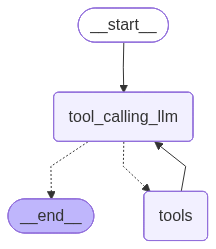

In [29]:
from IPython.display import display,Image
# node define for ai assistant
def tool_calling_llm(state:State):
    return {"messages":[model_with_tools.invoke(state["messages"])]}

# build the graph

builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm",tools_condition)
builder.add_edge("tools","tool_calling_llm")
builder.add_edge("tool_calling_llm",END)


graph = builder.compile(checkpointer=memory)

display(Image(graph.get_graph().draw_mermaid_png()))

In [31]:
config={"configurable":{"thread_id":"1"}}

In [ ]:

response = graph.invoke({"messages":"1706.03762"})
for r in response['messages']:
    r.pretty_print() 

In [ ]:
response = graph.invoke({"messages":"Hey my name is abhi"})
for r in response['messages']:
    r.pretty_print() 
    

================================ Human Message =================================

Hey my name is abhi
================================== Ai Message ==================================

Hello Abhi! How can I assist you today? 😊


In [ ]:

response = graph.invoke({"messages":"hey give me recent news on ai then  please tell me the recent research paper on quantum computing"})
for r in response['messages']:
    r.pretty_print() 